## LiDAR-Based Tree Detection in Mixed Forests
## Task 5 : Convert Point Cloud to Voxel Grid



In [1]:
%%capture
! pip install laspy open3d

In [2]:
# Standard library imports
import os
import warnings
import collections
import itertools
from typing import Tuple, List, Union, Generator

# Numerical and data manipulation libraries
import numpy as np
import pandas as pd
import scipy
from scipy.spatial import KDTree

# Geospatial libraries
import geopandas as gpd
import open3d as o3d


# LAS (LiDAR) file handling
import laspy
from laspy import read

# Visualization libraries
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
def load_las_file(file_path: str) -> laspy.LasData:
    """
    Load a .las file and return the full laspy.LasData object.
    """
    try:
        las = laspy.read(file_path)
        return las  
    except Exception as e:
        print(f"Error loading file: {e}")
        return None


In [4]:
def shift_points_to_origin(points) -> np.ndarray:
    """
    Shift points to the origin (0, 0, 0) by subtracting the minimum coordinates.
    """
    return points - points.min(axis=0, keepdims=True)

In [5]:
def plot_shifted_lidar(lidar_file: str):
    """
    Plot a 3D LiDAR point cloud with ground points in red. Coordinates are shifted for better visualization.
    """
    try:
        las = laspy.read(lidar_file)
        points = np.stack([las.x, las.y, las.z], axis=1)
        classifications = las.classification

        # shift points to start from (0, 0, 0)
        points = shift_points_to_origin(points)
        ground_mask = classifications == 2
        ground_points = points[ground_mask]
        other_points = points[~ground_mask]

        file_name = os.path.splitext(os.path.basename(lidar_file))[0]

        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection="3d")

        ax.scatter(
            ground_points[:, 0],
            ground_points[:, 1],
            ground_points[:, 2],
            c="red",
            s=0.5,
            label="Ground Points",
        )

        ax.scatter(
            other_points[:, 0],
            other_points[:, 1],
            other_points[:, 2],
            c=other_points[:, 2],
            cmap="viridis",
            s=0.5,
        )

        ax.set_title("LiDAR Point Cloud Visualization (Shifted)")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")  

        ax.view_init(elev=30, azim=45)  
        ax.legend(loc="upper right", markerscale=5, fontsize=10)

        plt.figtext(0.5, 0.01, f"{file_name}", ha="center", style="italic")

        plt.show()

    except Exception as e:
        print(f"Error visualizing LiDAR file: {e}")


In [6]:
def calculate_iqr_outliers(z_values: np.ndarray) -> Tuple[float, float]:
    """
    Calculate the lower and upper bounds for outliers in Z values based on the IQR method.
    """
    q1 = np.percentile(z_values, 25)  # 25th percentile (Q1)
    q3 = np.percentile(z_values, 75)  # 75th percentile (Q3)
    iqr = q3 - q1  # Interquartile range (IQR)
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    return lower_bound, upper_bound


In [7]:
def plot_z_distribution(z_values: np.ndarray, ax, file_name: str):
    """
    Plot the Z-value distribution for the given z-values on a specific subplot, with outlier boundaries.
    """
    lower_bound, upper_bound = calculate_iqr_outliers(z_values)
    
    # Plot histogram
    ax.hist(z_values, bins=50, color="green", alpha=0.7, label="Z Values")
    
    # Add IQR outlier lines
    ax.axvline(lower_bound, color="red", linestyle="--", label=f"Lower: {lower_bound:.2f}")
    ax.axvline(upper_bound, color="red", linestyle="--", label=f"Upper: {upper_bound:.2f}")
    
    ax.set_title(file_name, fontsize=10)
    ax.set_xlabel("Z Value (Height)", fontsize=8)
    ax.set_ylabel("Frequency", fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)


In [8]:
LAS_GROUND_CLASS = 2

def normalize_cloud_height(las):
    out = las.xyz.copy()
    assert np.any(las.classification == LAS_GROUND_CLASS)
    ground_level = scipy.interpolate.griddata(
        points=las.xyz[las.classification == LAS_GROUND_CLASS, :2], # X, Y coordinates of the ground points.
        values=las.xyz[las.classification == LAS_GROUND_CLASS, 2], # The Z-values (heights) of the ground points.
        xi=las.xyz[:, :2], # X, Y coordinates of all points in the las file.
        method="nearest",
    )
    out[:, 2] -= ground_level # Subtracts the interpolated ground height (ground_level) from the Z-value of each point.
    return out

In [9]:
def preprocess_data(las) -> np.ndarray:
    """
    Preprocess LiDAR points by normalizing heights relative to ground and removing outliers.
    """
    normalized_cloud = normalize_cloud_height(las)
    
    z_values = normalized_cloud[:, 2]
    lower_bound, upper_bound = calculate_iqr_outliers(z_values)
    mask = (z_values >= lower_bound) & (z_values <= upper_bound)
    
    filtered_points = normalized_cloud[mask]
    
    return filtered_points


In [10]:
def split_dataset(data: List, train_ratio: float = 0.7) -> Tuple[List, List]:
    """
    Splits the dataset into training and testing sets based on the given ratio.
    """
    split_idx = int(len(data) * train_ratio)
    
    train_data = data[:split_idx]
    test_data = data[split_idx:]
    
    return train_data, test_data

In [11]:
def local_maxima_filter(cloud: np.ndarray, window_size: float, height_threshold: float) -> np.ndarray:
    """Detect local maxima in the point cloud with a fixed window size."""
    
    assert isinstance(cloud, np.ndarray), f"Cloud needs to be a numpy array, not {type(cloud)}"
    
    cloud = cloud[cloud[:, 2] > height_threshold]
    tree = KDTree(data=cloud)
    seen_mask = np.zeros(cloud.shape[0], dtype=bool)
    local_maxima = []

    for i, point in enumerate(cloud):
        if seen_mask[i]:
            continue
        neighbor_indices = tree.query_ball_point(point, window_size)
        highest_neighbor = neighbor_indices[cloud[neighbor_indices, 2].argmax()]
        seen_mask[neighbor_indices] = True
        seen_mask[highest_neighbor] = False 
        # This may lead to not every point being marked as seen in the end, but it does not matter,
        # because by the time the seen value is overwritten the point is already processed
        if i == highest_neighbor:
            local_maxima.append(i)
    return cloud[local_maxima]

In [12]:
def _ndarray_to_tuple(array: np.ndarray) -> tuple:
    """Convert an array to a tuple, replacing np.nan with None."""
    return tuple(None if np.isnan(x) else x for x in array)

In [13]:
def match_candidates(
    ground_truth: np.ndarray,
    candidates: np.ndarray,
    *,
    max_distance: float,
    max_height_difference: float,
) -> list[dict]:
    """Match ground truth trees to candidates."""

    distance_matrix = scipy.spatial.distance_matrix(
        x=ground_truth[:, :2],
        y=candidates[:, :2],
    )
    indices = np.nonzero(distance_matrix <= max_distance)  # (ground_truths, candidates)
    distances = distance_matrix[indices]
    sparse_distances = sorted((d, pair) for d, pair in zip(distances, zip(*indices)))

    ground_truth_matched_mask = np.zeros(ground_truth.shape[0], dtype=bool)
    candidates_matched_mask = np.zeros(candidates.shape[0], dtype=bool)
    out = []

    for distance, (i, j) in sparse_distances:
        if ground_truth_matched_mask[i] and candidates_matched_mask[j]:
            continue

        if (
            not np.isnan(ground_truth[i][2])
            and abs(ground_truth[i][2] - candidates[j][2]) > max_height_difference
        ):
            continue

        if ground_truth_matched_mask[i]:
            candidates_matched_mask[j] = True
            out.append(
                {
                    "ground_truth": None,
                    "candidate": _ndarray_to_tuple(candidates[j]),
                    "class": "FP",
                    "distance": None,
                }
            )
        elif candidates_matched_mask[j]:
            ground_truth_matched_mask[i] = True
            out.append(
                {
                    "ground_truth": _ndarray_to_tuple(ground_truth[i]),
                    "candidate": None,
                    "class": "FN",
                    "distance": None,
                }
            )
        else:
            ground_truth_matched_mask[i] = True
            candidates_matched_mask[j] = True
            out.append(
                {
                    "ground_truth": _ndarray_to_tuple(ground_truth[i]),
                    "candidate": _ndarray_to_tuple(candidates[j]),
                    "class": "TP",
                    "distance": distance,
                }
            )

    out.extend(
        {
            "ground_truth": _ndarray_to_tuple(point),
            "candidate": None,
            "class": "FN",
            "distance": None,
        }
        for point in ground_truth[~ground_truth_matched_mask]
    )

    out.extend(
        {
            "ground_truth": None,
            "candidate": tuple(point),
            "class": "FP",
            "distance": None,
        }
        for point in candidates[~candidates_matched_mask]
    )

    return out

In [14]:
def crop_by_other(points: np.ndarray, other: np.ndarray) -> np.ndarray:
    """Crop points by the extent of other."""
    hull = scipy.spatial.ConvexHull(other[:, :2])
    vertex_points = hull.points[hull.vertices]
    delaunay = scipy.spatial.Delaunay(vertex_points)
    within_hull = delaunay.find_simplex(points[:, :2]) >= 0
    return points[within_hull]

In [15]:
def calculate_metrics(group):
    classes = collections.Counter(group["class"])
    metrics = {
        "recall": classes["TP"] / (classes["TP"] + classes["FN"]),
        "precision": classes["TP"] / (classes["TP"] + classes["FP"]),
    }
    if metrics["recall"] + metrics["precision"] > 0:
        metrics["f1"] = 2 * metrics["recall"] * metrics["precision"]
        metrics["f1"] = metrics["f1"] / (metrics["recall"] + metrics["precision"])
    else:
        metrics["f1"] = 0
    metrics["avg_dist"] = group["distance"].mean()
    return round(pd.Series(metrics), 2)

In [16]:
def point_cloud_to_voxel_grid(points: np.ndarray, voxel_size: float) -> o3d.geometry.VoxelGrid:
    """
    Convert a point cloud to a voxel grid using Open3D.
    """
    # Create Open3D point cloud object
    point_cloud = o3d.geometry.PointCloud()
    point_cloud.points = o3d.utility.Vector3dVector(points)
    
    # Create voxel grid from point cloud
    voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(point_cloud, voxel_size=voxel_size)
    return voxel_grid

In [17]:
def voxel_grid_to_array(voxel_grid, voxel_size):
    """
    Convert an Open3D VoxelGrid into a binary 3D voxel grid.
    """
    # Get the grid indices of the occupied voxels
    voxel_indices = np.array([voxel.grid_index for voxel in voxel_grid.get_voxels()])

    # Compute the dimensions of the grid
    bounding_box = voxel_grid.get_max_bound() - voxel_grid.get_min_bound()
    grid_shape = np.ceil(bounding_box / voxel_size).astype(int)

    # Create a binary 3D array (grid)
    binary_grid = np.zeros(grid_shape, dtype=np.uint8)
    for idx in voxel_indices:
        binary_grid[tuple(idx)] = 1  # Mark the voxel as occupied

    return binary_grid


In [18]:
def visualize_binary_voxel_grid(binary_voxel_grid: np.ndarray, voxel_size=0.1, title="Binary Voxel Grid"):
    """
    Visualize a binary voxel grid as a 3D scatter plot with real-world scaling.
    """
    # Get indices of occupied voxels (where value is 1)
    occupied_indices = np.array(np.nonzero(binary_voxel_grid)).T

    # Scale indices by voxel size to align with real-world coordinates
    scaled_indices = occupied_indices * voxel_size

    # Plot the occupied voxels
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(scaled_indices[:, 0], scaled_indices[:, 1], scaled_indices[:, 2],
               c=scaled_indices[:, 2], cmap='viridis', marker='s', s=10, alpha=0.8)

    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    
    # Adjust view
    ax.view_init(elev=30, azim=45)

    plt.show()


### Preprocessing

In [19]:
plot_las_files = [f"../data/als/plot_{i:02d}.las" for i in range(1, 11)]

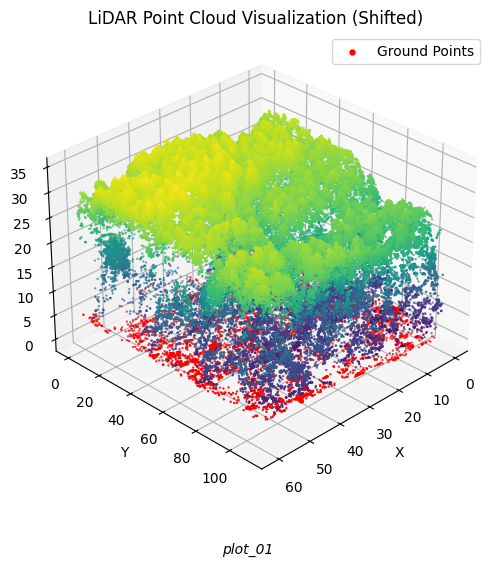

In [20]:
plot_shifted_lidar(plot_las_files[0])

Processing plot_01.las...
Processing plot_02.las...
Processing plot_03.las...
Processing plot_04.las...
Processing plot_05.las...
Processing plot_06.las...
Processing plot_07.las...
Processing plot_08.las...
Processing plot_09.las...
Processing plot_10.las...


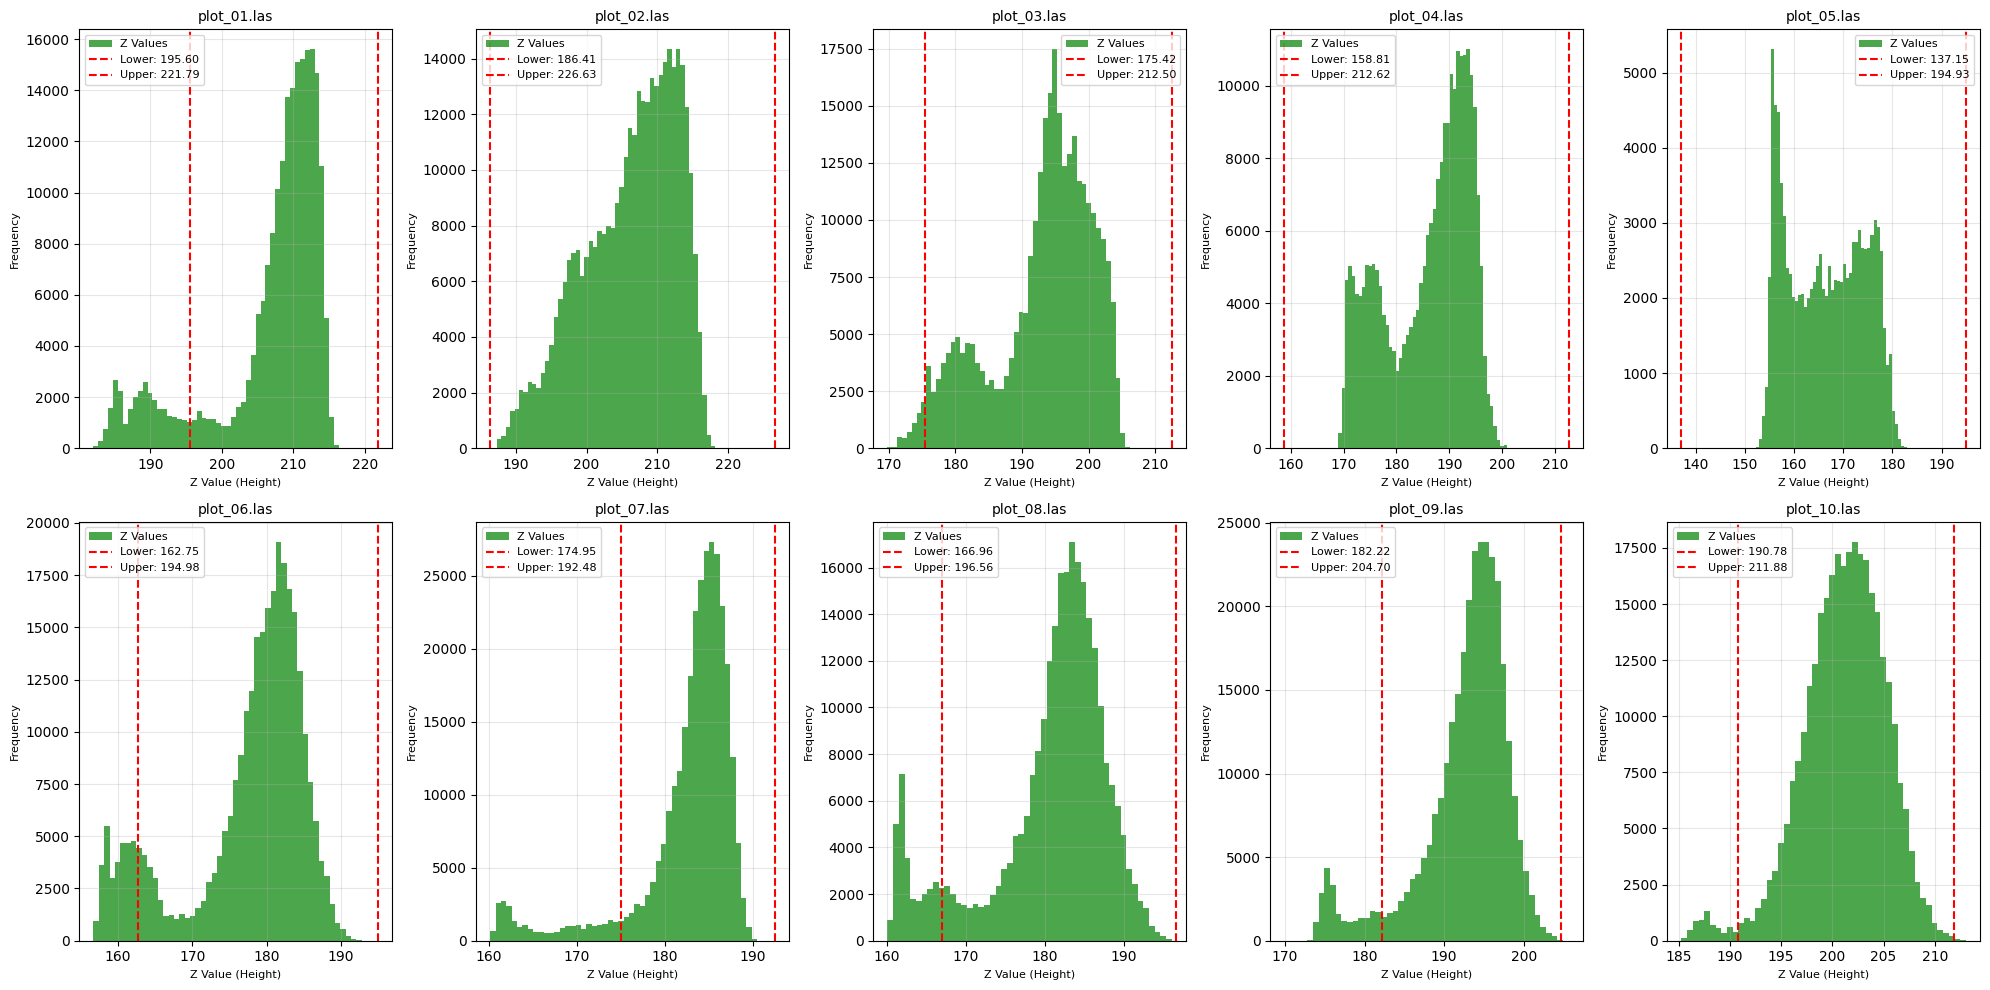

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))  
axes = axes.flatten()  

for i, file_path in enumerate(plot_las_files[:10]):  
    file_name = os.path.basename(file_path)
    print(f"Processing {file_name}...")
    
    las = load_las_file(file_path)
    if las is None or len(las.x) == 0:  
        print(f"Skipping {file_name} due to an error or no valid points.")
        continue
    
    plot_z_distribution(las.z, axes[i], file_name)

plt.tight_layout()
plt.show()


In [22]:
field_survey_gpd = gpd.read_file("../data/field_survey.geojson")
field_survey_gpd["coords"] = field_survey_gpd.get_coordinates().apply(
    lambda x: (x["x"], x["y"]),
    axis=1,
)

In [23]:
preprocessed_data = []  

for file_path in plot_las_files:
    
    las = load_las_file(file_path)  
    
    if las is not None and len(las.x) > 0:  
        preprocessed_points = preprocess_data(las)  
        preprocessed_data.append(preprocessed_points)  
    else:
        print(f"Skipping {file_path} due to no valid points.")

for i, points in enumerate(preprocessed_data):
    print(f"File {i + 1}: {len(points)} preprocessed points")


File 1: 186897 preprocessed points
File 2: 355599 preprocessed points
File 3: 282788 preprocessed points
File 4: 251251 preprocessed points
File 5: 105771 preprocessed points
File 6: 263587 preprocessed points
File 7: 284775 preprocessed points
File 8: 240625 preprocessed points
File 9: 289525 preprocessed points
File 10: 307468 preprocessed points


### Split data into train and test

In [24]:
train_ratio = 0.7
train_data, test_data = split_dataset(preprocessed_data, train_ratio)

### Detection Method

#### Local Maxima Filtering Algorithm

In [25]:
window_size = 3  # Radius for neighbor search
height_threshold = 2  # Minimum height to consider

for i, points in enumerate(preprocessed_data):
    local_maxima_points = local_maxima_filter(points, window_size, height_threshold)
    print(f"Detected {len(local_maxima_points)} local maxima in training file {i + 1}.")
    


Detected 236 local maxima in training file 1.
Detected 159 local maxima in training file 2.
Detected 248 local maxima in training file 3.
Detected 189 local maxima in training file 4.
Detected 221 local maxima in training file 5.
Detected 301 local maxima in training file 6.
Detected 160 local maxima in training file 7.
Detected 244 local maxima in training file 8.
Detected 186 local maxima in training file 9.
Detected 165 local maxima in training file 10.


In [26]:
raw_matches = {}
results = {}

for i, points in enumerate(preprocessed_data):  
    plot = i + 1  
    
    # Load ground truth data for the current plot
    subset = field_survey_gpd.query(f"plot == {plot}")
    ground_truth = subset.get_coordinates().to_numpy()
    ground_truth = np.hstack([ground_truth, subset["height"].to_numpy()[:, None]])

    # Detect local maxima
    candidates = local_maxima_filter(
        cloud=points,
        window_size=2,
        height_threshold=3,
    )

    # Crop candidates to match the ground truth area
    candidates = crop_by_other(candidates, ground_truth)

    # Match candidates to ground truth
    matches = match_candidates(
        ground_truth=ground_truth,
        candidates=candidates,
        max_distance=5,
        max_height_difference=3,
    )

    raw_matches[plot] = matches

    # Normalize matches into a DataFrame
    matches = pd.json_normalize(matches)
    matches["coords"] = matches["ground_truth"].map(lambda x: x if x is None else x[:2])

    # Merge with ground truth data
    results[plot] = pd.merge(
        left=subset.drop(columns=["d1", "d2"]),
        right=matches[["candidate", "class", "distance", "coords"]],
        on="coords",
        how="outer",
    )
    results[plot]["plot"] = plot


In [27]:
lmf_detection_results = pd.concat(results.values())
lmf_detection_results.to_csv("../results/lmf_detection_results.csv", index=False)
lmf_detection_results.query("distance.notnull()").head(n=10)

,plot,tree_no,species,dbh,age,height,angle,comment,geometry,coords,candidate,class,distance
3,1,340.0,Aspen,27.90,NaN,NaN,0.0,None,POINT (547072.854 6450351.849),"(547072.854, 6450351.849)","(547073.335, 6450352.8393, 29.093999999999994)",TP,1.100934
6,1,341.0,Aspen,32.50,88.0,32.2,0.0,None,POINT (547073.467 6450340.915),"(547073.466999999, 6450340.915)","(547073.853, 6450341.2953, 30.318000000000012)",TP,0.541871
11,1,345.0,Aspen,26.55,NaN,NaN,0.0,None,POINT (547074.184 6450336.833),"(547074.184, 6450336.83299999)","(547073.569, 6450337.2053, 16.254999999999995)",TP,0.718910
14,1,161.0,Aspen,22.35,NaN,NaN,0.0,None,POINT (547074.462 6450386.707),"(547074.462, 6450386.707)","(547073.359, 6450385.8423, 17.385999999999996)",TP,1.401540
15,1,91.0,Fir,26.20,NaN,NaN,0.0,None,POINT (547074.581 6450403.037),"(547074.581, 6450403.03699999)","(547073.993, 6450403.3593, 25.72)",TP,0.670538
16,1,166.0,Aspen,28.80,79.0,29.7,0.0,None,POINT (547074.617 6450374.97),"(547074.616999999, 6450374.96999999)","(547074.353, 6450374.7473, 27.738)",TP,0.345386
17,1,5.0,Aspen,27.25,NaN,NaN,0.0,None,POINT (547074.669 6450415.573),"(547074.668999999, 6450415.57299999)","(547074.525, 6450414.0223, 26.752999999999986)",TP,1.557372
18,1,165.0,Birch,13.80,NaN,NaN,0.0,None,POINT (547074.779 6450376.124),"(547074.778999999, 6450376.12399999)","(547074.451, 6450375.6953, 14.046999999999997)",TP,0.539785
19,1,239.0,Birch,18.05,NaN,21.9,0.0,None,POINT (547075 6450371.652),"(547075.0, 6450371.65199999)","(547075.246, 6450372.1573, 20.04600000000002)",TP,0.562000
20,1,344.0,Aspen,25.00,NaN,NaN,0.0,None,POINT (547075.352 6450338.687),"(547075.351999999, 6450338.68699999)","(547076.314, 6450338.5733, 15.954000000000008)",TP,0.968696


In [28]:
lmf_metrics = lmf_detection_results.groupby("plot").apply(calculate_metrics, include_groups=False)
lmf_metrics

,recall,precision,f1,avg_dist
plot,,,,
1,0.58,0.67,0.62,0.76
2,0.48,0.56,0.52,0.79
3,0.61,0.42,0.50,1.11
4,0.56,0.38,0.46,1.04
5,0.65,0.45,0.53,1.02
6,0.59,0.41,0.48,0.81
7,0.43,0.66,0.52,1.02
8,0.62,0.45,0.52,0.83
9,0.42,0.69,0.52,0.93


In [29]:
print("\nAverage metrics across all plots:")
print(lmf_metrics.mean(numeric_only=True))



Average metrics across all plots:
recall       0.531
precision    0.547
f1           0.518
avg_dist     0.908
dtype: float64


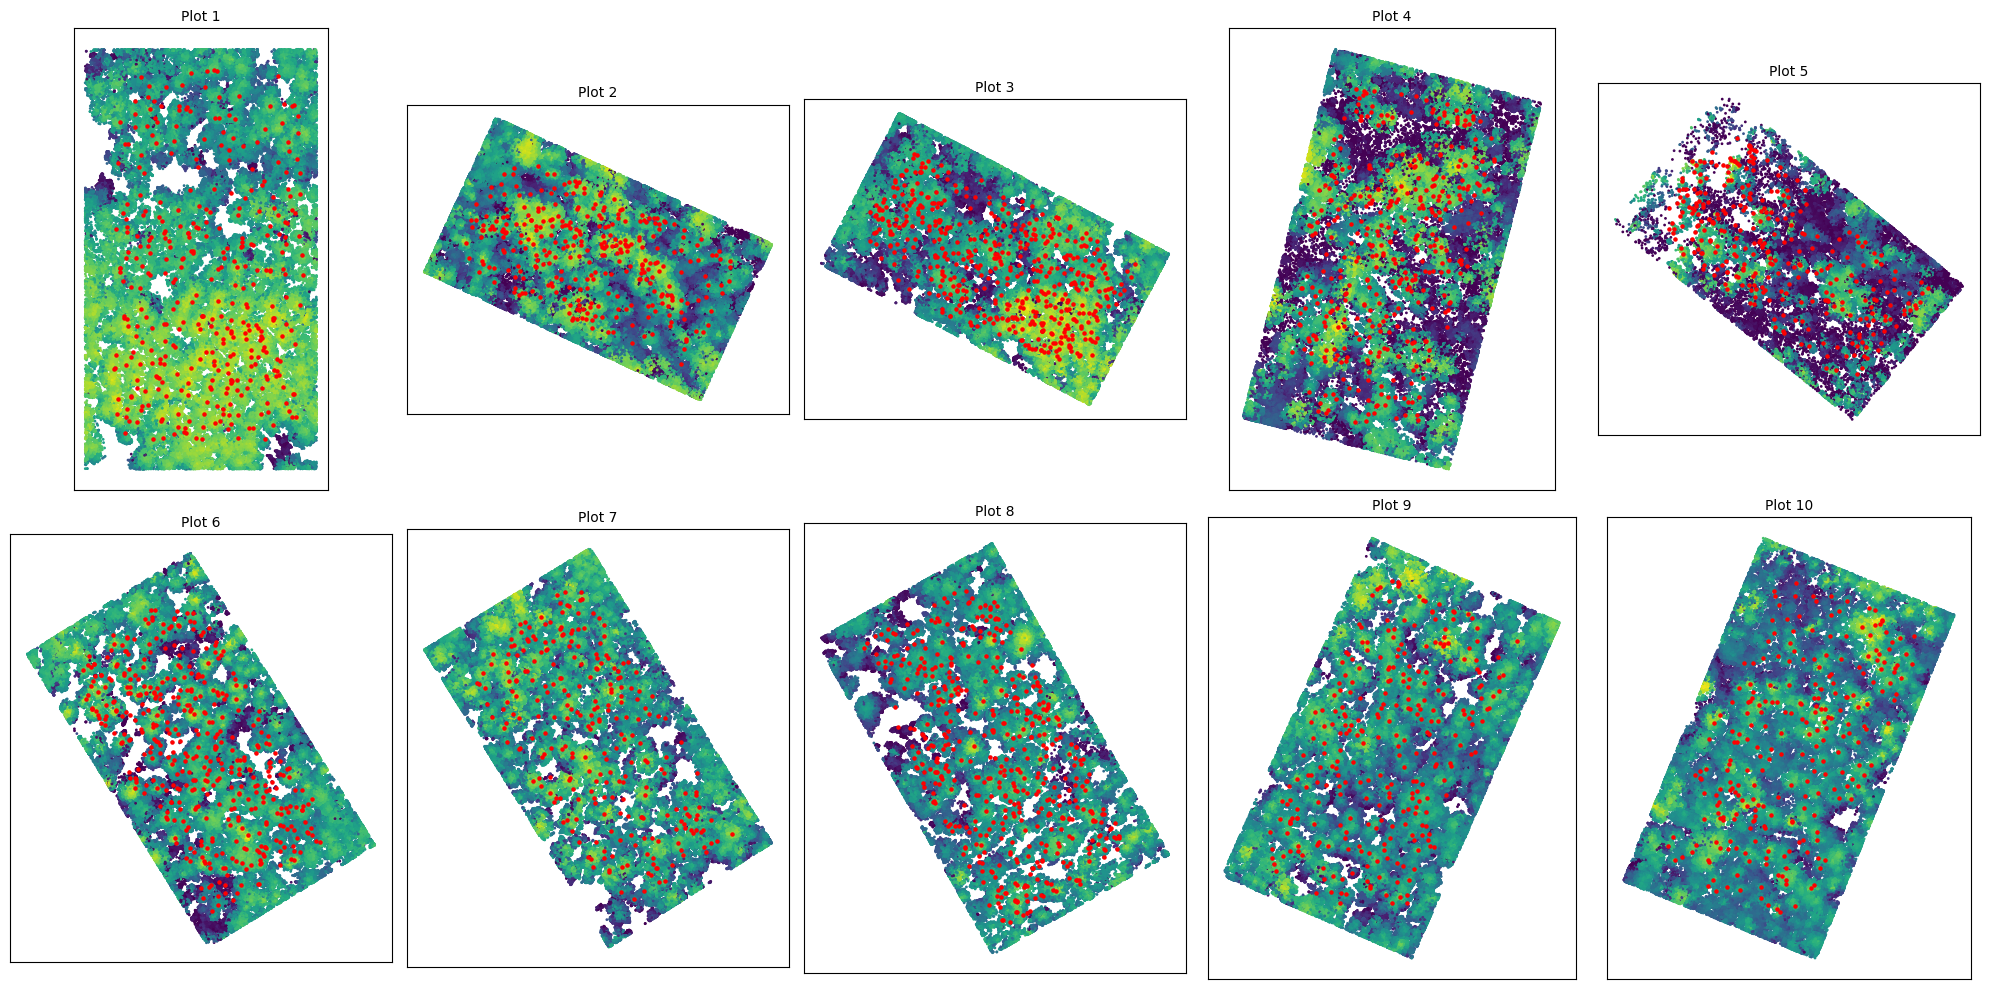

In [30]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for idx, (plot, matches) in enumerate(raw_matches.items()):  
    cloud = preprocessed_data[plot - 1]  
    local_maxima = np.array([
        m["candidate"] for m in matches if m["class"] in ["TP", "FP"]
    ])

    ax = axes[idx]

    sc = ax.scatter(cloud[:, 0], cloud[:, 1], c=cloud[:, 2], s=1, cmap="viridis")
    
    # Plot local maxima in red
    if len(local_maxima) > 0:
        ax.scatter(local_maxima[:, 0], local_maxima[:, 1], c="red", s=5, label="Local Maxima")
    
    ax.set_title(f"Plot {plot}", fontsize=10)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()


#### Convert Point Cloud to Voxel Grid

In [31]:
voxel_size = 0.1  # Size of the voxel in meters
binary_voxel_arrays = []  

for i, points in enumerate(preprocessed_data):  
    # Create Open3D VoxelGrid
    voxel_grid = point_cloud_to_voxel_grid(points, voxel_size=voxel_size)

    # Convert to binary 3D array
    binary_voxel_array = voxel_grid_to_array(voxel_grid, voxel_size)
    binary_voxel_arrays.append(binary_voxel_array)

    # Count the number of occupied voxels (where value == 1)
    occupied_voxel_count = np.sum(binary_voxel_array)

    # Print summary for the current plot
    print(f"Plot {i + 1}:")
    print(f"  Total Occupied Voxels: {occupied_voxel_count}")
    print(f"  Voxel Array Shape (X, Y, Z): {binary_voxel_array.shape}\n")

    # Save binary grid as a .npy file
    np.save(f"../results/voxels/binary_voxel_grid_plot_{i + 1}.npy", binary_voxel_array)


Plot 1:
  Total Occupied Voxels: 172357
  Voxel Array Shape (X, Y, Z): (611, 1108, 189)

Plot 2:
  Total Occupied Voxels: 316490
  Voxel Array Shape (X, Y, Z): (1300, 1051, 289)

Plot 3:
  Total Occupied Voxels: 245242
  Voxel Array Shape (X, Y, Z): (1300, 1090, 260)

Plot 4:
  Total Occupied Voxels: 216689
  Voxel Array Shape (X, Y, Z): (890, 1258, 300)

Plot 5:
  Total Occupied Voxels: 95544
  Voxel Array Shape (X, Y, Z): (1270, 1173, 290)

Plot 6:
  Total Occupied Voxels: 226536
  Voxel Array Shape (X, Y, Z): (1150, 1290, 293)

Plot 7:
  Total Occupied Voxels: 249856
  Voxel Array Shape (X, Y, Z): (1141, 1308, 161)

Plot 8:
  Total Occupied Voxels: 207583
  Voxel Array Shape (X, Y, Z): (1105, 1303, 288)

Plot 9:
  Total Occupied Voxels: 252046
  Voxel Array Shape (X, Y, Z): (1032, 1296, 226)

Plot 10:
  Total Occupied Voxels: 271851
  Voxel Array Shape (X, Y, Z): (1012, 1286, 206)



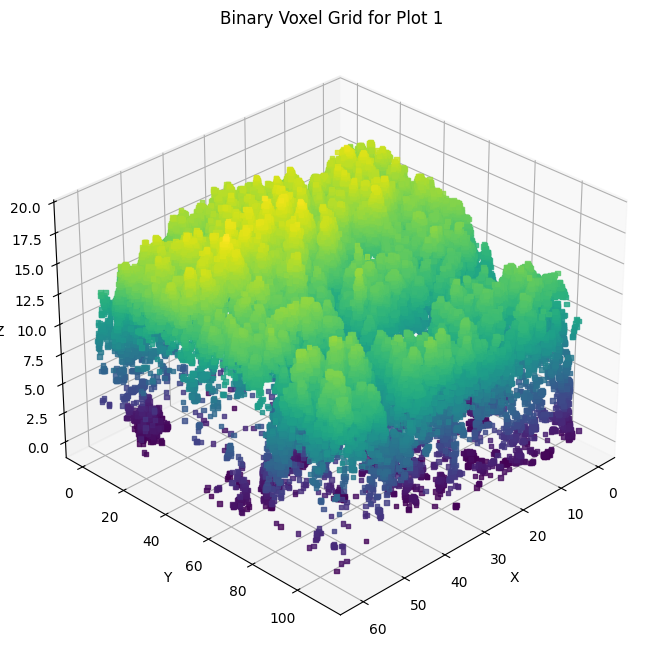

In [47]:
#hhh
visualize_binary_voxel_grid(binary_voxel_arrays[0], title="Binary Voxel Grid for Plot 1", voxel_size=0.1)

#### Advanced DNN architecture

### Comparison